# Etape 1
## Distribution de x_wins et is_draw - le dataset est-il équilibré?

Percentage of X wins: 67.75%
Percentage of Draws: 29.86%
Percentage of O wins: 2.40%


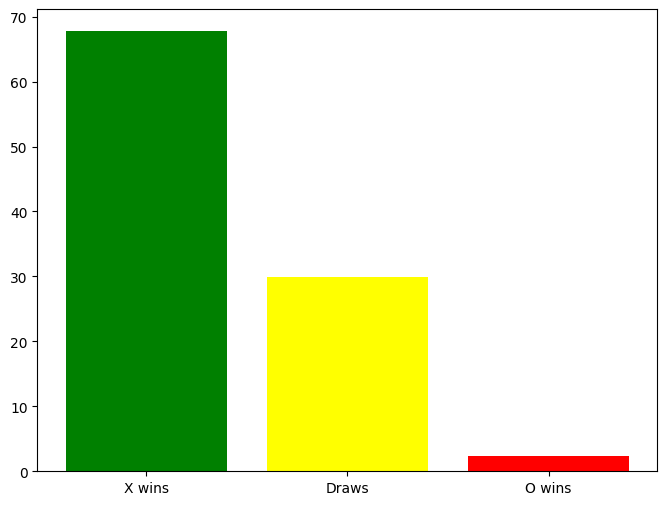

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("ressources/dataset.csv")

percentages_wins = df["x_wins"].value_counts(normalize=True) * 100
percentages_wins = percentages_wins[1]

percentages_draws = df["is_draw"].value_counts(normalize=True) * 100
percentages_draws = percentages_draws[1]

percentages_loses = 100 - (percentages_wins + percentages_draws)

percentages = [percentages_wins, percentages_draws, percentages_loses]
labels = ["X wins", "Draws", "O wins"]
plt.figure(figsize=(8, 6))
plt.bar(labels, percentages, color=["green", "yellow", "red"])

print(f"Percentage of X wins: {percentages_wins:.2f}%")
print(f"Percentage of Draws: {percentages_draws:.2f}%")
print(f"Percentage of O wins: {percentages_loses:.2f}%")

=> On peut remarquer que le dataset n'est pas équilibré 

# Quelle case est le plus souvent occupée par X dans les états où il gagne ?

c0_x : 72896
c1_x : 76136
c2_x : 72896
c3_x : 76136
c4_x : 69656
c5_x : 76136
c6_x : 72896
c7_x : 76136
c8_x : 72896


<BarContainer object of 9 artists>

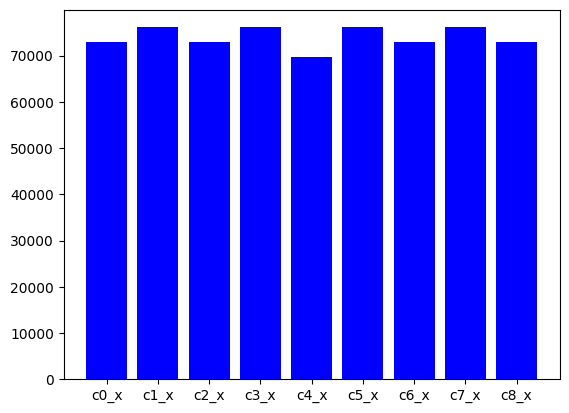

In [24]:
another_copy = df.copy()
wins = another_copy.where(another_copy["x_wins"] == 1).dropna()

arrays = ["c0_x", "c1_x", "c2_x", "c3_x", "c4_x", "c5_x", "c6_x", "c7_x", "c8_x"]
case_accuracy = []

for array in arrays:
    case_accuracy.append(df[array].value_counts()[1])
    print(array, ":", df[array].value_counts()[1])

plt.bar(arrays, case_accuracy, color="blue")

=> On peut remarquer qu'on a 4 cases ayant la même occurence max : 
c1_x, c3_x, c5_x et c7_x = 76 136

# Corrélation entre les features et chaque cible - heatmap

<Axes: >

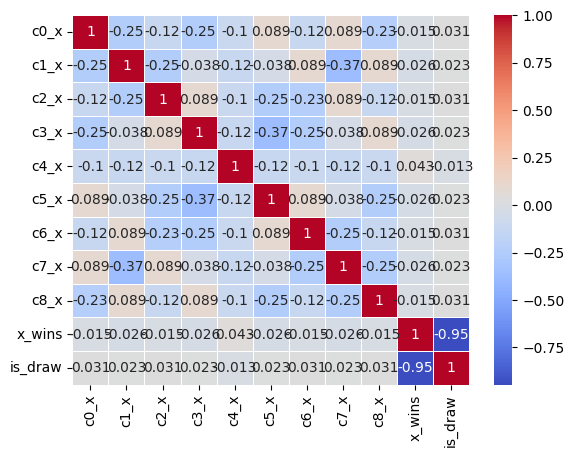

In [25]:
copy_df = df.copy()
copy_df.drop(columns=["c0_o", "c1_o", "c2_o", "c3_o", "c4_o", "c5_o", "c6_o", "c7_o", "c8_o"], inplace=True)
sns.heatmap(copy_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)

## Etape 2 : modèle machine learning

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score

X = df.drop("x_wins", axis=1)
Y = df["x_wins"]

X_train,X_test, Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=0)

pipe = make_pipeline(StandardScaler(),LogisticRegression())
pipe.fit(X_train,Y_train)

accuracy = pipe.score(X_test,Y_test)
print(f"Accuracy (win): {accuracy:.2%}")

f1_score_wins = f1_score(Y_test, pipe.predict(X_test))
print(f"F1 Score: {f1_score_wins:.2%}")

matrix_confusion = confusion_matrix(Y_test, pipe.predict(X_test))
print("Confusion Matrix: \n", matrix_confusion)

Accuracy (win): 97.54%
F1 Score: 98.21%
Confusion Matrix: 
 [[10882   817]
 [   69 24305]]


In [27]:
Xd = df.drop("is_draw", axis=1)
Yd = df["is_draw"]

Xd_train,Xd_test, Yd_train,Yd_test = train_test_split(Xd,Yd,test_size=0.2,random_state=0)

pipe = make_pipeline(StandardScaler(),LogisticRegression())
pipe.fit(Xd_train,Yd_train)

accuracyD = pipe.score(Xd_test,Yd_test)
print(f"Accuracy (draw): {accuracyD:.2%}")

f1_score_draws = f1_score(Yd_test, pipe.predict(Xd_test))
print(f"F1 Score: {f1_score_draws:.2%}")

matrix_confusionD = confusion_matrix(Yd_test, pipe.predict(Xd_test))
print("Confusion Matrix: \n", matrix_confusionD)

Accuracy (draw): 97.74%
F1 Score: 96.30%
Confusion Matrix: 
 [[24619   588]
 [  229 10637]]


=> On peut remarquer que le modèle avec x_wins est le plus facile à apprendre.

model decision tree

Decision Tree Classifier trained successfully. 0.9760480369924762


[Text(0.625, 0.875, 'x[18] <= 0.5\ngini = 0.437\nsamples = 180361\nvalue = [58169.0, 122192.0]'),
 Text(0.5, 0.625, 'x[4] <= 0.5\ngini = 0.066\nsamples = 126512\nvalue = [4320, 122192]'),
 Text(0.5625, 0.75, 'True  '),
 Text(0.25, 0.375, 'x[12] <= 0.5\ngini = 0.096\nsamples = 77116\nvalue = [3888.0, 73228.0]'),
 Text(0.125, 0.125, 'gini = 0.124\nsamples = 47514\nvalue = [3156, 44358]'),
 Text(0.375, 0.125, 'gini = 0.048\nsamples = 29602\nvalue = [732, 28870]'),
 Text(0.75, 0.375, 'x[2] <= 0.5\ngini = 0.017\nsamples = 49396\nvalue = [432, 48964]'),
 Text(0.625, 0.125, 'gini = 0.022\nsamples = 32976\nvalue = [360, 32616]'),
 Text(0.875, 0.125, 'gini = 0.009\nsamples = 16420\nvalue = [72, 16348]'),
 Text(0.75, 0.625, 'gini = 0.0\nsamples = 53849\nvalue = [53849, 0]'),
 Text(0.6875, 0.75, '  False')]

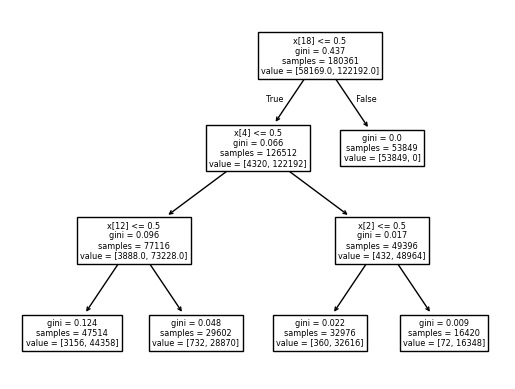

In [28]:
from sklearn import tree
clf = tree.DecisionTreeClassifier(max_depth=3)
clf = clf.fit(X, Y)

print("Decision Tree Classifier trained successfully.", clf.score(X, Y))
tree.plot_tree(clf)

Decision Tree Classifier for draws trained successfully. 0.9760480369924762


[Text(0.625, 0.875, 'x[18] <= 0.5\ngini = 0.418\nsamples = 144288\nvalue = [101305, 42983]'),
 Text(0.5, 0.625, 'x[4] <= 0.5\ngini = 0.139\nsamples = 46470\nvalue = [3487.0, 42983.0]'),
 Text(0.5625, 0.75, 'True  '),
 Text(0.25, 0.375, 'x[6] <= 0.5\ngini = 0.188\nsamples = 29960\nvalue = [3147, 26813]'),
 Text(0.125, 0.125, 'gini = 0.242\nsamples = 16610\nvalue = [2338, 14272]'),
 Text(0.375, 0.125, 'gini = 0.114\nsamples = 13350\nvalue = [809, 12541]'),
 Text(0.75, 0.375, 'x[0] <= 0.5\ngini = 0.04\nsamples = 16510\nvalue = [340, 16170]'),
 Text(0.625, 0.125, 'gini = 0.052\nsamples = 10639\nvalue = [285, 10354]'),
 Text(0.875, 0.125, 'gini = 0.019\nsamples = 5871\nvalue = [55, 5816]'),
 Text(0.75, 0.625, 'gini = 0.0\nsamples = 97818\nvalue = [97818, 0]'),
 Text(0.6875, 0.75, '  False')]

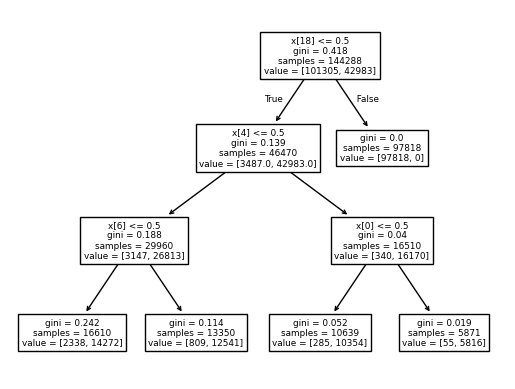

In [29]:
clfd = clf.fit(Xd_train, Yd_train)

print("Decision Tree Classifier for draws trained successfully.", clfd.score(Xd, Yd))
tree.plot_tree(clfd)

model Gradiant Boosting

In [30]:
from sklearn.ensemble import HistGradientBoostingClassifier


In [ ]:
clf1 = HistGradientBoostingClassifier()
clf1.fit(X_train,Y_train)
print(clf1.score(X_train,Y_train)*100)

99.71834265722634


In [33]:
clf2 = HistGradientBoostingClassifier()
clf2.fit(Xd_train,Yd_train)
print(clf2.score(Xd_train,Yd_train)*100)

99.99722776668885
